# Exercise 1 – Handwritten Digit Recognition using kNN

Use a k-Nearest Neighbors (kNN) classifier to identify handwritten digits based on appearance similarity.

**Dataset:** Scikit-learn's built-in `Digits` dataset. It contains 8×8 grayscale handwritten images of digits 0–9, so no external dataset download is required.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
# Load the handwritten digits dataset
digits = load_digits()
X = digits.data
y = digits.target

print('Number of samples:', X.shape[0])
print('Number of features per image:', X.shape[1])
print('Classes:', np.unique(y))

Number of samples: 1797
Number of features per image: 64
Classes: [0 1 2 3 4 5 6 7 8 9]


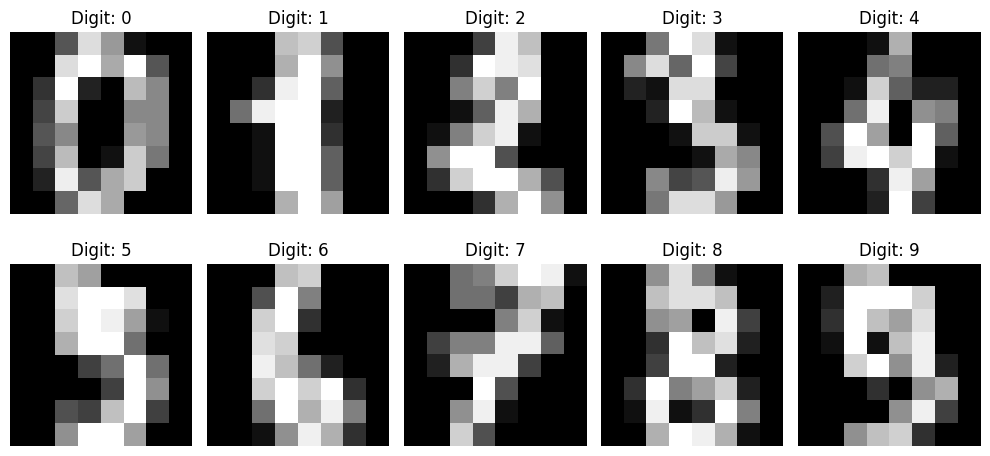

In [3]:
# Display sample handwritten digits
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for ax, image, label in zip(axes.ravel(), digits.images[:10], digits.target[:10]):
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Digit: {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Split the dataset

80% of the samples are used for training and 20% for testing.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 1437
Testing samples: 360


## Train the kNN classifier

Here, **k = 5**. The classifier finds the five nearest training samples and predicts the digit using majority voting.

In [5]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'kNN Accuracy (k={k}): {accuracy * 100:.2f}%')

kNN Accuracy (k=5): 98.33%


In [6]:
print('Classification Report:\n')
print(classification_report(y_test, y_pred))

print('Confusion Matrix:\n')
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      1.00      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.94      0.91      0.93        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360

Confusion Matrix:

[[36  0  0  0  0  0  0  0  0  0]
 [ 0 36  0  0  0  0  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]


## Predict a new handwritten digit

The following code selects one unseen test image and predicts its digit.

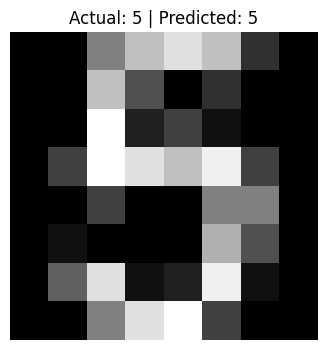

Actual digit: 5
Predicted digit: 5


In [7]:
sample_index = 0
sample = X_test[sample_index].reshape(1, -1)
actual_digit = y_test[sample_index]
predicted_digit = knn.predict(sample)[0]

plt.figure(figsize=(4, 4))
plt.imshow(X_test[sample_index].reshape(8, 8), cmap='gray')
plt.title(f'Actual: {actual_digit} | Predicted: {predicted_digit}')
plt.axis('off')
plt.show()

print('Actual digit:', actual_digit)
print('Predicted digit:', predicted_digit)

## Conclusion

The kNN classifier recognizes handwritten digits by comparing a new image with similar training images. The majority class among the nearest neighbors is used as the prediction.